In [1]:
import numpy as np
import pandas as pd
import pickle

import importlib

In [ ]:
import utils
import plot_umap_maps
import plot_ecg_bands

importlib.reload(utils)
importlib.reload(plot_umap_maps)
importlib.reload(plot_ecg_bands)


from utils import make_data_class
from plot_umap_maps import plot_UMAP_datasets, make_2d_UMAP_datapairs
from plot_ecg_bands import plot_bands_datasets

ImportError: cannot import name 'plot_umap_datasets' from 'plot_umap_maps' (/home/ECG_Quality_Evaluation/plot_umap_maps.py)

#### Load Test Data

In [3]:
#load test data
real_norm_df = pd.read_pickle("/home/ecg_trust/ECG_trustability_with_CyclaGAN/Data/train_generators_data/test_df_cyclegan_NORM.pickle")
real_asmi_df = pd.read_pickle("/home/ecg_trust/ECG_trustability_with_CyclaGAN/Data/train_generators_data/test_df_cyclegan_ASMI.pickle")
real_imi_df = pd.read_pickle("/home/ecg_trust/ECG_trustability_with_CyclaGAN/Data/train_generators_data/test_df_cyclegan_IMI.pickle")

real_norm = np.stack(real_norm_df["prep_subsample 40x12"].to_numpy()).squeeze()
real_asmi = np.stack(real_asmi_df["prep_subsample 40x12"].to_numpy()).squeeze()
real_imi = np.stack(real_imi_df["prep_subsample 40x12"].to_numpy()).squeeze()

real_norm_label  = "NORM"
real_asmi_label = "ASMI"
real_imi_label = "IMI"

In [4]:
#Fake ecgs

asmi_fnorm = np.load("/home/ecg_trust/ECG_trustability_with_CyclaGAN/Generated_Data/ASMI_from_NORM_cyGan_generated.npy").squeeze()
asmi_fimi = np.load("/home/ecg_trust/ECG_trustability_with_CyclaGAN/Generated_Data/ASMI_from_IMI_cyGan_generated.npy").squeeze()

imi_fnorm = np.load("/home/ecg_trust/ECG_trustability_with_CyclaGAN/Generated_Data/IMI_from_NORM_cyGan_generated.npy").squeeze()
imi_fasmi = np.load("/home/ecg_trust/ECG_trustability_with_CyclaGAN/Generated_Data/IMI_from_ASMI_cyGan_generated.npy").squeeze()

norm_fasmi = np.load("/home/ecg_trust/ECG_trustability_with_CyclaGAN/Generated_Data/NORM_from_ASMI_cyGan_generated.npy").squeeze()
norm_fimi = np.load("/home/ecg_trust/ECG_trustability_with_CyclaGAN/Generated_Data/NORM_from_IMI_cyGan_generated.npy").squeeze()

asmi_fnorm_label = "ASMI_from_NORM"
asmi_fimi_label = "ASMI_from_IMI"

imi_fnorm_label = "IMI_from_NORM"
imi_fasmi_label = "IMI_from_ASMI"

norm_fasmi_label = "NORM_from_ASMI"
norm_fimi_label = "NORM_from_IMI"

print(norm_fasmi.shape, norm_fimi.shape, asmi_fnorm.shape, asmi_fimi.shape, imi_fnorm.shape, imi_fasmi.shape)

(3850, 40, 12) (3192, 40, 12) (3564, 40, 12) (3192, 40, 12) (3564, 40, 12) (3850, 40, 12)


### Test DataClass

In [8]:
real_labels_list = ["ASMI", "ASMI", "IMI", "IMI", "NORM",  "NORM"]
real_data_list = [real_asmi, real_asmi, real_imi, real_imi, real_norm, real_norm]
gen_labels_list = ["asmi_fimi","asmi_fnorm","imi_fasmi", "imi_fnorm", "norm_fasmi",  "norm_fimi",  ]
gen_data_list = [asmi_fimi, asmi_fnorm, imi_fasmi, imi_fnorm, norm_fasmi, norm_fimi]

ecg_datasets = make_data_class(real_labels_list, real_data_list, gen_labels_list, gen_data_list)

### TEST Ecg BANDS

In [ ]:
save_bands_folder = None #"/home/ECG_Quality_Evaluation/Test_Figs"
sampling_freq = 500
plot_bands_datasets(ecg_datasets, save_figs_folder = save_bands_folder, 
                    bands = True, ecg_sampling_frequency = sampling_freq, 
                    show_avg_ecg = True, grid_on = False)

### Test UMAP Plots

In [15]:
import plot_umap_maps

importlib.reload(plot_umap_maps)

from plot_umap_maps import plot_UMAP_datasets, make_2d_UMAP_datapairs


In [16]:
umap_ecg_datapairs = make_2d_UMAP_datapairs(ecg_datasets, random_state = 42)

  0%|          | 0/6 [00:00<?, ?it/s]/home/ECG_Quality_Evaluation/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
 17%|█▋        | 1/6 [00:47<03:55, 47.11s/it]/home/ECG_Quality_Evaluation/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
 33%|███▎      | 2/6 [01:22<02:40, 40.16s/it]/home/ECG_Quality_Evaluation/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


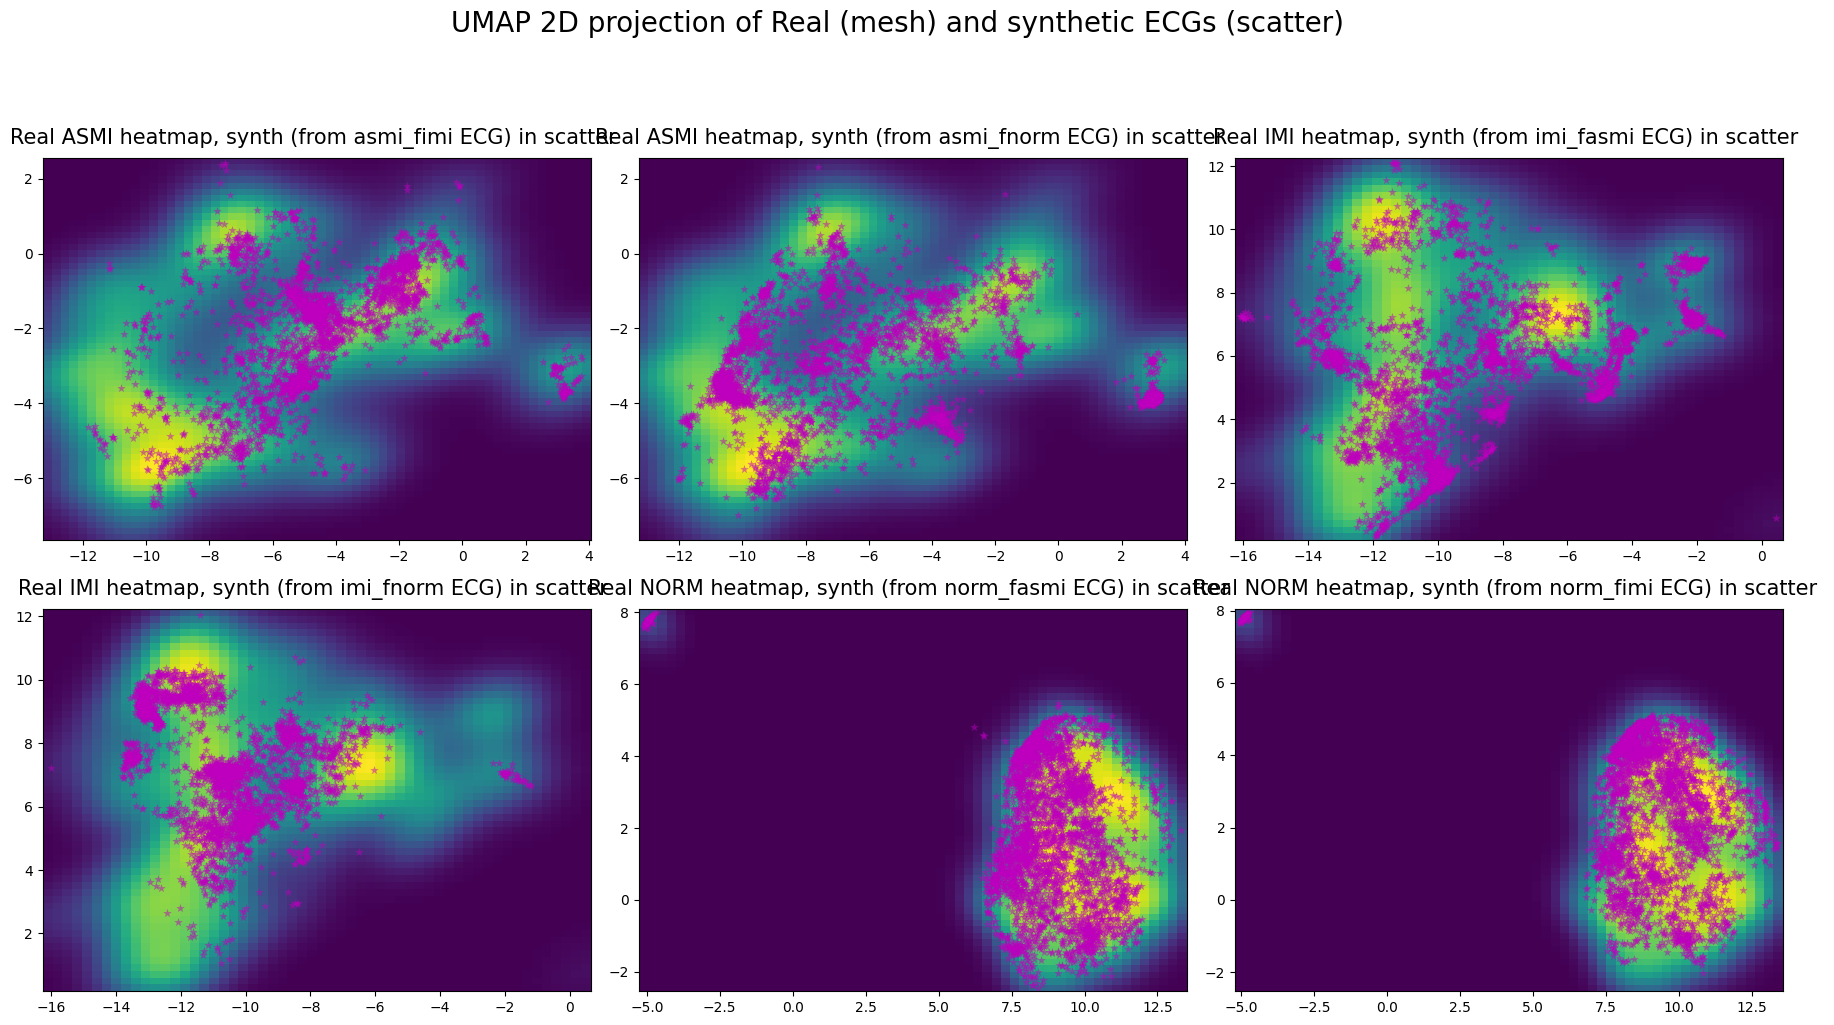

In [17]:
plot_UMAP_datasets(umap_ecg_datapairs, title_on = True, save_path = None, save_single = None )

In [18]:
np.save("/home/ECG_Quality_Evaluation/TestData/TEST_real_norm.npy", real_norm[:10])
np.save("/home/ECG_Quality_Evaluation/TestData/TEST_real_asmi.npy", real_asmi[:10])

np.save("/home/ECG_Quality_Evaluation/TestData/TEST_fake_asmi_from_norm.npy", asmi_fnorm[:10])
np.save("/home/ECG_Quality_Evaluation/TestData/TEST_fake_norm_from_asmi.npy", norm_fasmi[:10])